In [1]:
#Import Libraries
###Data Handling
import pandas as pd
import numpy as np

###Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

###Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load supply chain dataset
supply_df = pd.read_csv('supply_chain.csv')

# View first 5 rows
supply_df.head()

,Order_ID,Supplier_Name,Product_Type,Inventory_Level,Shipping_Time,Shipping_Cost,Warehouse,Order_Quantity,Delivery_Status,Delay_Days,Region
0,1001,Supplier C,Furniture,490,7,345.07,Warehouse 2,78,Delayed,4,East
1,1002,Supplier D,Electronics,307,4,121.81,Warehouse 2,64,Delayed,6,South
2,1003,Supplier D,Clothing,205,6,470.44,Warehouse 1,47,Delayed,3,East
3,1004,Supplier D,Electronics,144,5,492.58,Warehouse 2,46,Delayed,6,West
4,1005,Supplier D,Clothing,384,9,448.60,Warehouse 2,28,Delayed,2,East


In [3]:
#Shape Of Supply Chain Dataset
supply_df.shape

(500, 11)

In [4]:
# Column names in supply chain dataset
supply_df.columns

Index(['Order_ID', 'Supplier_Name', 'Product_Type', 'Inventory_Level',
       'Shipping_Time', 'Shipping_Cost', 'Warehouse', 'Order_Quantity',
       'Delivery_Status', 'Delay_Days', 'Region'],
      dtype='object')

In [5]:
# Check data types in supply chain dataset
supply_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         500 non-null    int64  
 1   Supplier_Name    500 non-null    object 
 2   Product_Type     500 non-null    object 
 3   Inventory_Level  500 non-null    int64  
 4   Shipping_Time    500 non-null    int64  
 5   Shipping_Cost    500 non-null    float64
 6   Warehouse        500 non-null    object 
 7   Order_Quantity   500 non-null    int64  
 8   Delivery_Status  500 non-null    object 
 9   Delay_Days       500 non-null    int64  
 10  Region           500 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 43.1+ KB


In [6]:
# Check missing values in supply chain dataset
supply_df.isnull().sum()

Order_ID           0
Supplier_Name      0
Product_Type       0
Inventory_Level    0
Shipping_Time      0
Shipping_Cost      0
Warehouse          0
Order_Quantity     0
Delivery_Status    0
Delay_Days         0
Region             0
dtype: int64

In [7]:
# Statistical summary of supply chain dataset
supply_df.describe()

,Order_ID,Inventory_Level,Shipping_Time,Shipping_Cost,Order_Quantity,Delay_Days
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,270.216000,6.022000,282.431340,53.370000,3.462000
std,144.481833,132.752566,2.601355,129.681696,25.712865,2.278363
min,1001.000000,52.000000,2.000000,50.780000,10.000000,0.000000
25%,1125.750000,150.750000,4.000000,177.085000,31.000000,1.000000
50%,1250.500000,265.000000,6.000000,284.660000,53.500000,3.000000
75%,1375.250000,384.000000,8.000000,391.055000,76.000000,5.000000
max,1500.000000,498.000000,10.000000,499.920000,100.000000,7.000000


In [8]:
# Average delay days by supplier
supply_df.groupby('Supplier_Name')['Delay_Days'].mean()

Supplier_Name
Supplier A    3.531746
Supplier B    3.352459
Supplier C    3.553719
Supplier D    3.412214
Name: Delay_Days, dtype: float64

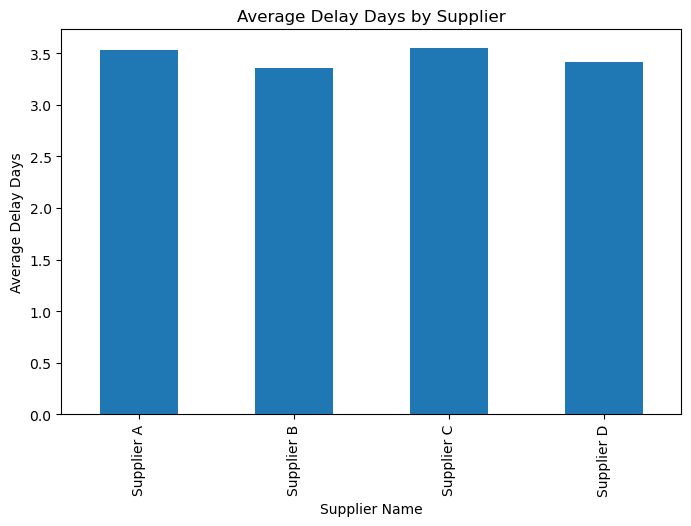

In [9]:
# Supplier-wise average delay plot
supply_df.groupby('Supplier_Name')['Delay_Days'].mean().plot(kind='bar', figsize=(8,5))

plt.title('Average Delay Days by Supplier')
plt.xlabel('Supplier Name')
plt.ylabel('Average Delay Days')
plt.show()

In [10]:
###Insight
#Supplier C having the highest delays means that supplier may be creating bottlenecks in the supply chain

In [11]:
# Average shipping cost by region
supply_df.groupby('Region')['Shipping_Cost'].mean()

Region
East     274.486850
North    280.414715
South    272.325221
West     305.514035
Name: Shipping_Cost, dtype: float64

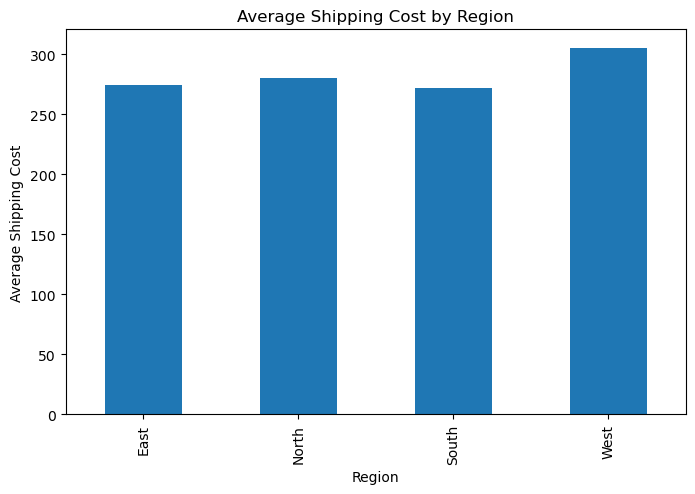

In [12]:
supply_df.groupby('Region')['Shipping_Cost'].mean().plot(kind='bar', figsize=(8,5))

plt.title('Average Shipping Cost by Region')
plt.xlabel('Region')
plt.ylabel('Average Shipping Cost')
plt.show()

In [13]:
# One-hot encoding categorical columns
supply_df = pd.get_dummies(supply_df, columns=[
    'Supplier_Name',
    'Product_Type',
    'Warehouse',
    'Region',
    'Delivery_Status'
], drop_first=True)

In [14]:
supply_df.head()

,Order_ID,Inventory_Level,Shipping_Time,Shipping_Cost,Order_Quantity,Delay_Days,Supplier_Name_Supplier B,Supplier_Name_Supplier C,Supplier_Name_Supplier D,Product_Type_Electronics,Product_Type_Food,Product_Type_Furniture,Warehouse_Warehouse 2,Warehouse_Warehouse 3,Region_North,Region_South,Region_West,Delivery_Status_Delivered,Delivery_Status_In Transit
0,1001,490,7,345.07,78,4,False,True,False,False,False,True,True,False,False,False,False,False,False
1,1002,307,4,121.81,64,6,False,False,True,True,False,False,True,False,False,True,False,False,False
2,1003,205,6,470.44,47,3,False,False,True,False,False,False,False,False,False,False,False,False,False
3,1004,144,5,492.58,46,6,False,False,True,True,False,False,True,False,False,False,True,False,False
4,1005,384,9,448.60,28,2,False,False,True,False,False,False,True,False,False,False,False,False,False


# Define Features (X) and Target (y)

In [15]:
# Define target
y_supply = supply_df['Delay_Days']

# Features
X_supply = supply_df.drop(['Delay_Days', 'Order_ID'], axis=1)

# Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_supply, y_supply, test_size=0.2, random_state=42
)

# Import Model

In [18]:
from sklearn.ensemble import RandomForestRegressor

In [19]:
# Create model
rf_supply = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_supply.fit(Xs_train, ys_train)

# Predict
ys_pred = rf_supply.predict(Xs_test)

# Model Evaluation

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [21]:
mae_s = mean_absolute_error(ys_test, ys_pred)
rmse_s = np.sqrt(mean_squared_error(ys_test, ys_pred))

mae_s, rmse_s

(2.2192999999999996, np.float64(2.563062035924999))

# Feature Importance

In [22]:
importance_supply = pd.DataFrame({
'Feature': X_supply.columns,
'Importance': rf_supply.feature_importances_
})

importance_supply = importance_supply.sort_values(
by='Importance',
ascending=False
)

importance_supply.head(10)

,Feature,Importance
2,Shipping_Cost,0.235431
0,Inventory_Level,0.226473
3,Order_Quantity,0.160878
1,Shipping_Time,0.095297
11,Warehouse_Warehouse 3,0.031897
15,Delivery_Status_Delivered,0.024865
9,Product_Type_Furniture,0.024791
10,Warehouse_Warehouse 2,0.023499
14,Region_West,0.023486
8,Product_Type_Food,0.023273


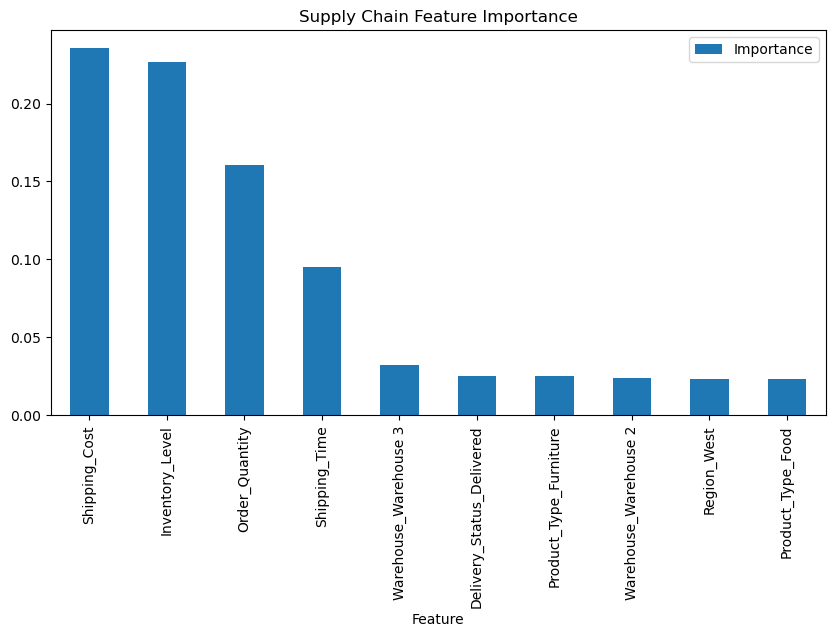

In [23]:
#Visualize
importance_supply.head(10).plot(
x='Feature',
y='Importance',
kind='bar',
figsize=(10,5)
)

plt.title('Supply Chain Feature Importance')
plt.show()

# Install XGBOOST

In [24]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
#Import
from xgboost import XGBRegressor

In [26]:
xgb_supply = XGBRegressor(
n_estimators=200,
learning_rate=0.05,
max_depth=6,
random_state=42
)

xgb_supply.fit(Xs_train, ys_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [27]:
# Predict
ys_pred_xgb = xgb_supply.predict(Xs_test)

In [28]:
#Evaluate
mae_sxgb = mean_absolute_error(ys_test, ys_pred_xgb)
rmse_sxgb = np.sqrt(mean_squared_error(ys_test, ys_pred_xgb))

mae_sxgb, rmse_sxgb

(2.129491090774536, np.float64(2.4935939730446868))

In [29]:
###Insight
#Built and compared Random Forest and XGBoost models for shipment delay prediction; selected XGBoost after improving prediction error over baseline model.

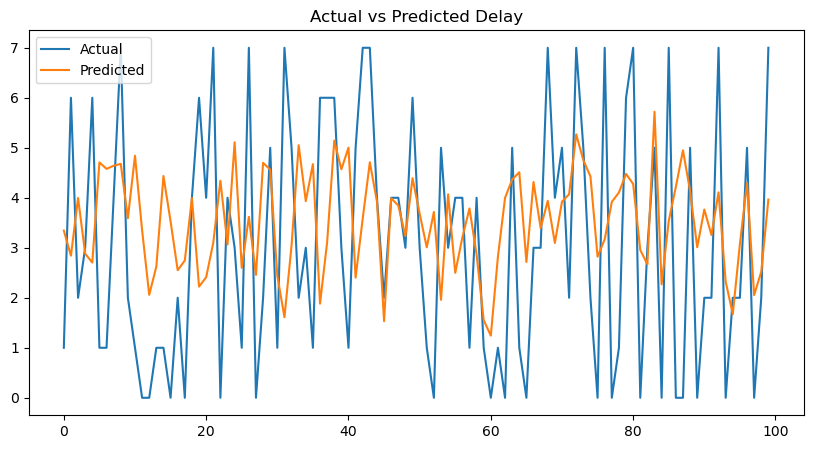

In [30]:
# Prediction Plot
plt.figure(figsize=(10,5))

plt.plot(
ys_test.values[:100],
label='Actual'
)

plt.plot(
ys_pred_xgb[:100],
label='Predicted'
)

plt.legend()
plt.title('Actual vs Predicted Delay')
plt.show()

In [31]:
#r2_score:
from sklearn.metrics import r2_score

In [32]:
r2_score(ys_test,ys_pred_xgb)

-0.07438647747039795

In [33]:
###Insight
#Analyzed model limitations using negative R² and identified additional operational variables needed to improve delay prediction.

In [34]:
import pickle
with open('model_supply.pkl', 'wb') as f:
    pickle.dump(xgb_supply, f)